In [42]:
from sklearn.metrics import roc_auc_score

# Customer Churn Prediction

step 1 . imports

In [11]:
pip install pandas numpy matplotlib seaborn scikit-learn joblib jupyter notebook

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/89/3c/45c352094cfa60050bcbb967b1faf246b22e93cb459f2f907b600f2ceda5/scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Obtaining dependency information for joblib from https://files.pythonhosted.org/packages/7b/91/984aca2ec129e2757d1e4e3c81c3fcda9d0f85b74670a094cc443d9ee949/joblib-1.5.3-py3-none-any.whl.metadata
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Obtaining dependency information for jupyter from https://files.pythonhosted.org/packages/38/64/285f20a31679bf547b75602702f7800e74dbabae36ef324f716c02804753/jupyter-1.1.1-py2.py3-none-any.whl.metadata
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Obtaining dependency information for notebook from https://files.pythonhosted.org/packages/f8/aa/cbd1deb9f07446241e88f8d5fecccd95b249bca0b4e5482214a4d1714c49/notebook-7.5.5

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\admin\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\~umpy.libs\\libopenblas64__v0.3.23-293-gc2f4bdbb-gcc_10_3_0-65e29aac85b9409a6008e2dc84b1cc09.dll'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import sys
!{sys.executable} -m pip install scikit-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/89/3c/45c352094cfa60050bcbb967b1faf246b22e93cb459f2f907b600f2ceda5/scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Obtaining dependency information for scipy>=1.10.0 from https://files.pythonhosted.org/packages/95/da/0d1df507cf574b3f224ccc3d45244c9a1d732c81dcb26b1e8a766ae271a8/scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Obtaining dependency information for joblib>=1.3.0 from https://files.pythonhosted.org/packages/7b/91/984aca2ec129e2757d1e4e3c81c3fcda9d0f85b74670a094cc443d9ee949/joblib-1.5.3-py3-none-any.whl.metadata
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp311-cp3


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from  collections import Counter


# Sklearn
from  sklearn.model_selection import  train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from  sklearn.preprocessing import  StandardScaler , MinMaxScaler ,OneHotEncoder , LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


#models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier , AdaBoostClassifier 
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

#metrics & utilities
from sklearn.metrics import accuracy_score, precision_score,recall_score , f1_score ,confusion_matrix,classification_report
import joblib
import warnings
warnings.filterwarnings("ignore")



#Display settings

sns.set_theme(style= "whitegrid" , palette = 'muted',font_scale= 1.05)
pd.set_option('display.max_columns',200)







STEP 2 . Load the data

In [5]:
# Load dataset (adjust path if needed)
df = pd.read_csv("customer_dataa.csv")
print("Shape:",df.shape)
df.head()

Shape: (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


step 3. Initial inspection 

In [7]:
# info & summary
display(df.info())
display(df.describe(include = 'all').T)

#missing values
print("\nMissing values per column:")
print(df.isnull().sum)

# Target distributuon
print("\nChurn value counts:")
print(df['churn'].value_counts(normalize = False))
print("\nChurn proprotion:")
print(df['churn'].value_counts(normalize=True))

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
credit_score,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
country,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
products_number,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0
credit_card,10000.0,NaN,NaN,NaN,0.7055,0.45584,0.0,0.0,1.0,1.0,1.0
active_member,10000.0,NaN,NaN,NaN,0.5151,0.499797,0.0,0.0,1.0,1.0,1.0



Missing values per column:
<bound method DataFrame.sum of       customer_id  credit_score  country  gender    age  tenure  balance  \
0           False         False    False   False  False   False    False   
1           False         False    False   False  False   False    False   
2           False         False    False   False  False   False    False   
3           False         False    False   False  False   False    False   
4           False         False    False   False  False   False    False   
...           ...           ...      ...     ...    ...     ...      ...   
9995        False         False    False   False  False   False    False   
9996        False         False    False   False  False   False    False   
9997        False         False    False   False  False   False    False   
9998        False         False    False   False  False   False    False   
9999        False         False    False   False  False   False    False   

      products_number  credi

step 4.  Exploratory Data Analysis (visualizations)

we'll look at distrubutions of numeric features, realtionships with churn and categorial features

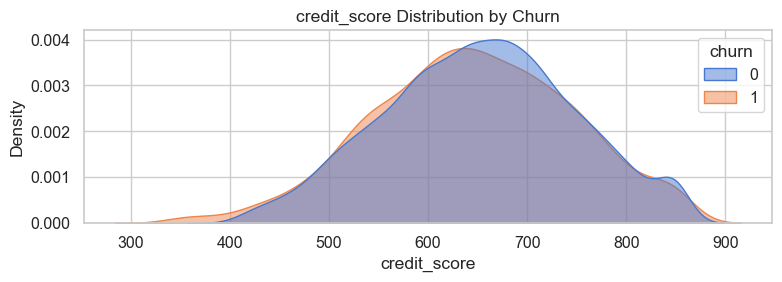

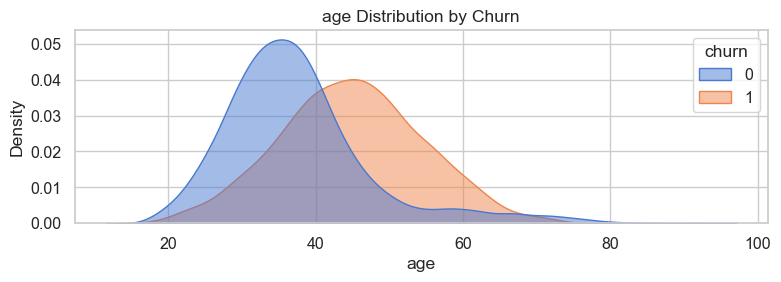

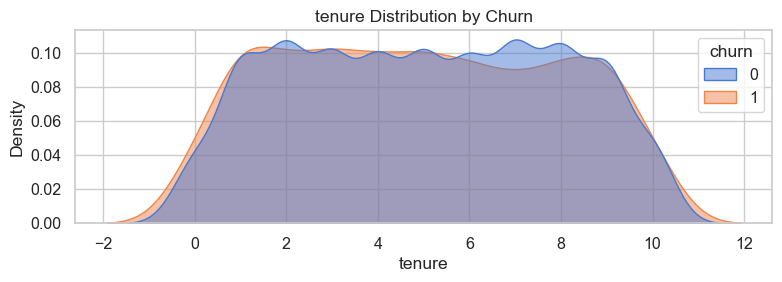

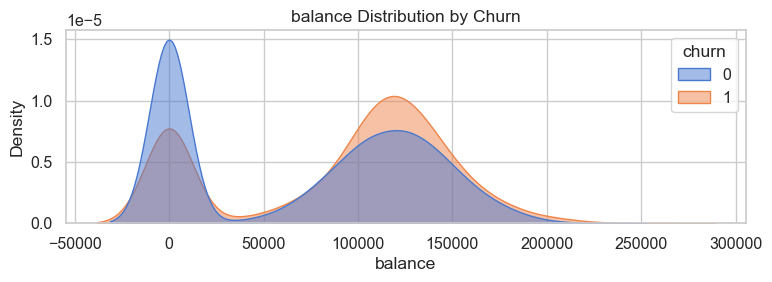

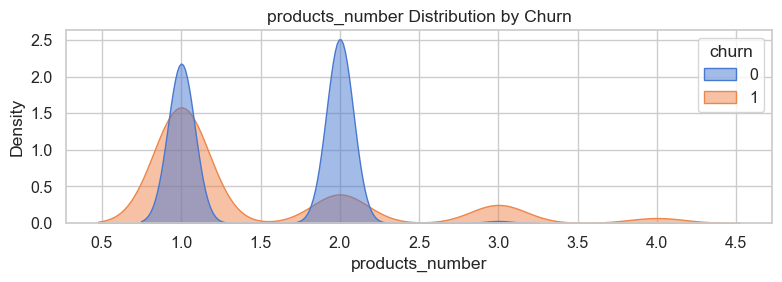

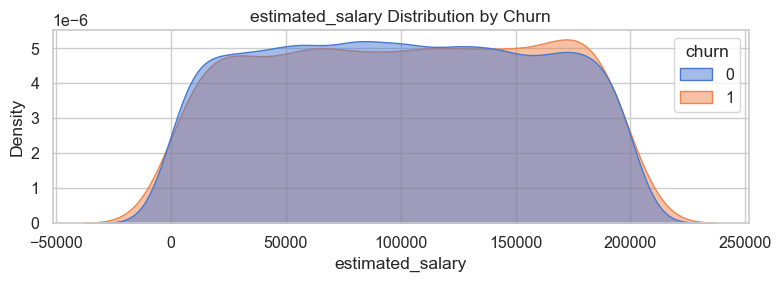

In [10]:
num_cols = ['credit_score','age','tenure','balance','products_number','estimated_salary']

# --- Distribution plots
for col in num_cols:
    plt.figure(figsize=(8,3))
    sns.kdeplot(data= df, x= col, hue = 'churn',fill= True,common_norm = False, alpha = 0.5)
    plt.title(f'{col} Distribution by Churn')
    plt.tight_layout()
    plt.show()

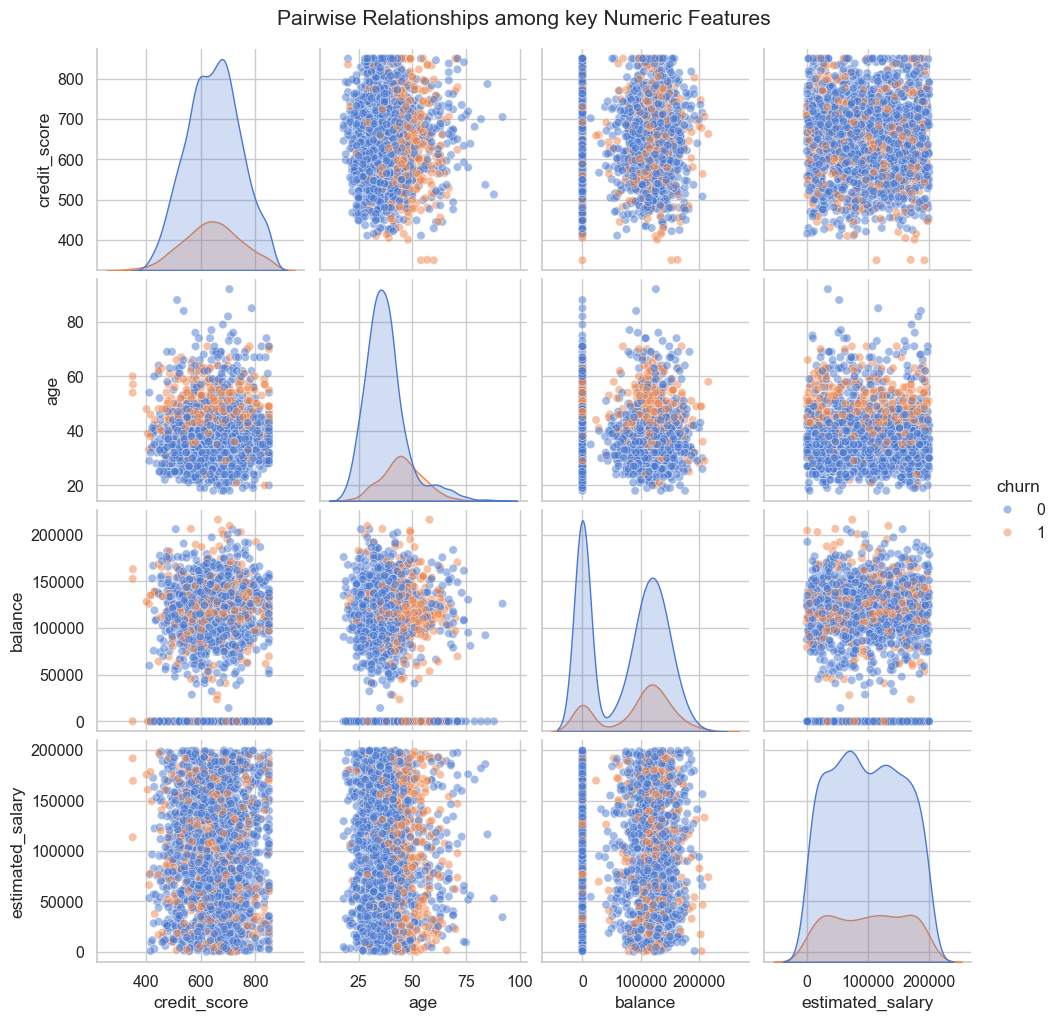

In [13]:
#---- Pairplot (sampled for speed)
sns.pairplot(df.sample(frac = 0.2,random_state = 42),
             vars = ['credit_score','age','balance','estimated_salary'],
             hue = 'churn',diag_kind ='kde',plot_kws ={'alpha':0.5})
plt.suptitle('Pairwise Relationships among key Numeric Features', y = 1.02)
plt.show()

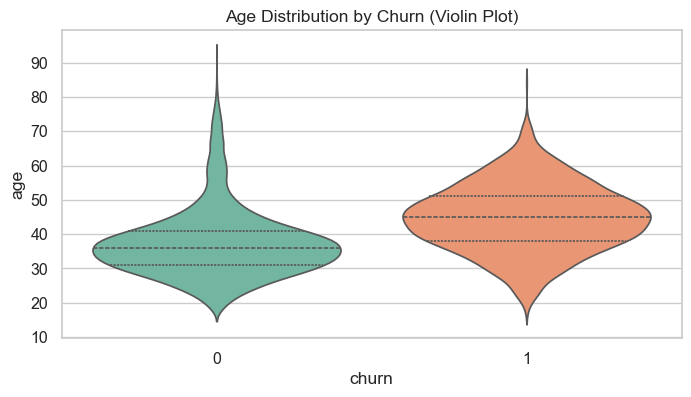

In [14]:
# --- Violin plot
plt.figure(figsize= (8,4))
sns.violinplot(data = df, x= 'churn', y ='age',inner = 'quart', palette = 'Set2')
plt.title('Age Distribution by Churn (Violin Plot)')
plt.show()

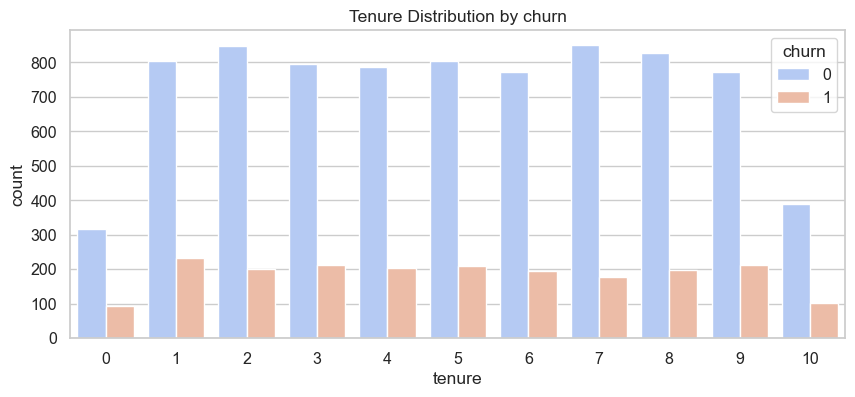

In [15]:
#---- trnure distribution
plt.figure(figsize=(10,4))
sns.countplot(data= df,x= 'tenure',hue='churn',palette = 'coolwarm')
plt.title('Tenure Distribution by churn')
plt.show()

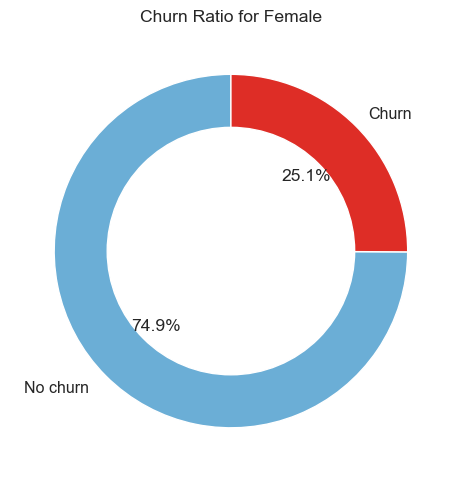

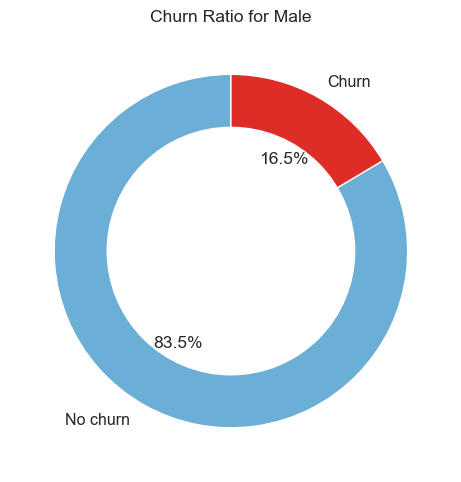

In [17]:
# --- Gender vs Churn Donut Chart

gender_counts = df.groupby('gender')['churn'].value_counts(normalize = True).unstack().fillna(0)
for gender in gender_counts.index:
    plt.figure(figsize= (5,5))
    plt.pie(gender_counts.loc[gender],labels=['No churn ','Churn'],
            autopct='%1.1f%%',startangle = 90 ,colors =['#6baed6','#de2d26'])
    center = plt.Circle((0,0),0.70,fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(center)
    plt.title(f'Churn Ratio for {gender}')
    plt.tight_layout()
    plt.show()

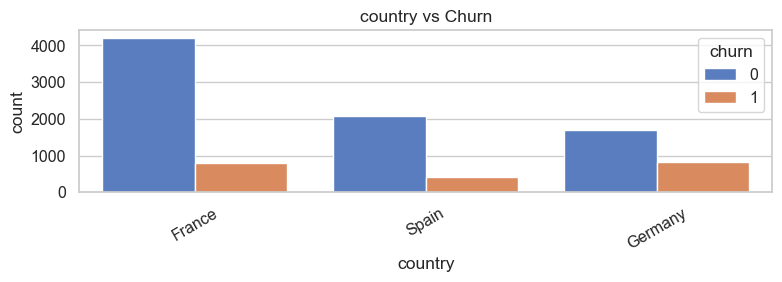

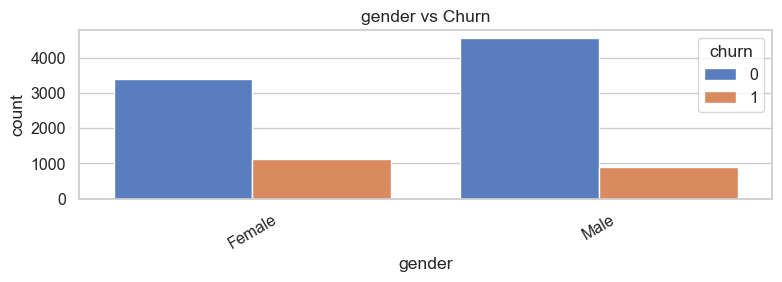

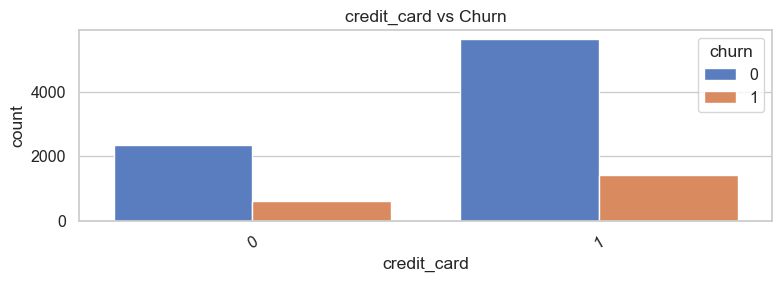

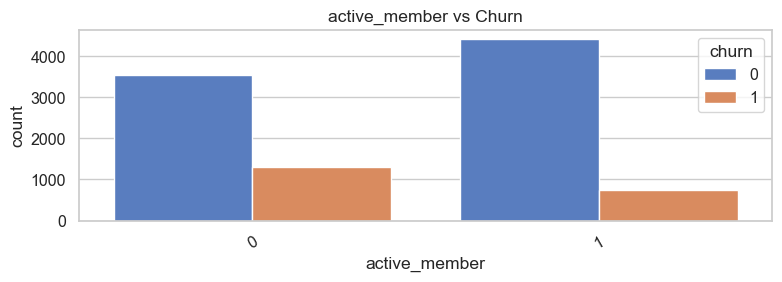

In [18]:
#--- Categorical features
cat_cols = ['country','gender','credit_card','active_member']
for c in cat_cols:
    plt.figure(figsize= (8,3))
    sns.countplot(data = df,x= c, hue='churn')
    plt.title(f'{c} vs Churn')
    plt.xticks(rotation= 30)
    plt.tight_layout()

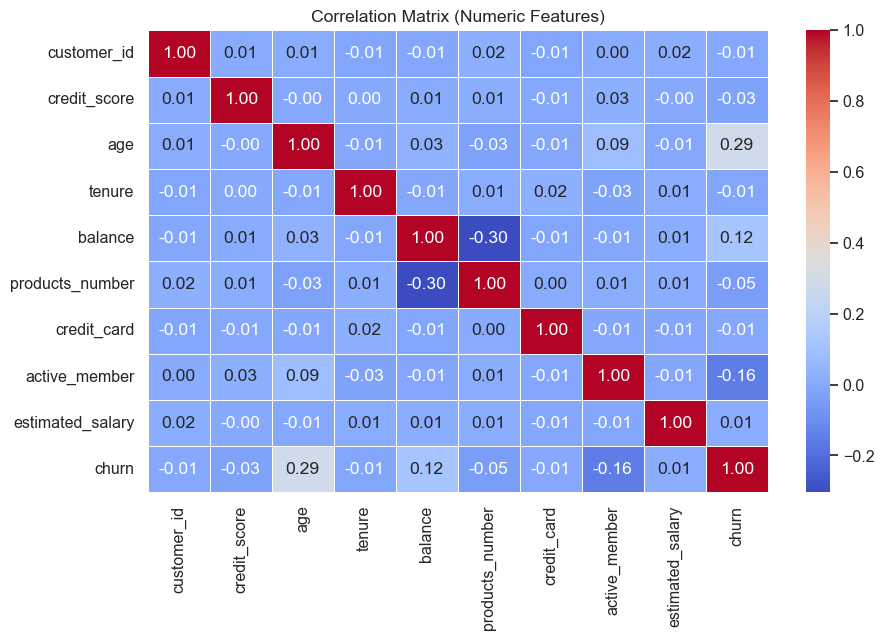

In [20]:
#--heatmap visualization
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot = True ,fmt ='.2f',cmap = 'coolwarm',linewidths= 0.5)
plt.title('Correlation Matrix (Numeric Features)')
plt.show()

In [22]:
# --- Numeric Corellation heatmap

numeric_data = df[num_cols] 
corr = numeric_data.corr()
corr.style.background_gradient(cmap='coolwarm')

,credit_score,age,tenure,balance,products_number,estimated_salary
credit_score,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.001384
age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.007201
tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.007784
balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,0.012797
products_number,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.014204
estimated_salary,-0.001384,-0.007201,0.007784,0.012797,0.014204,1.000000


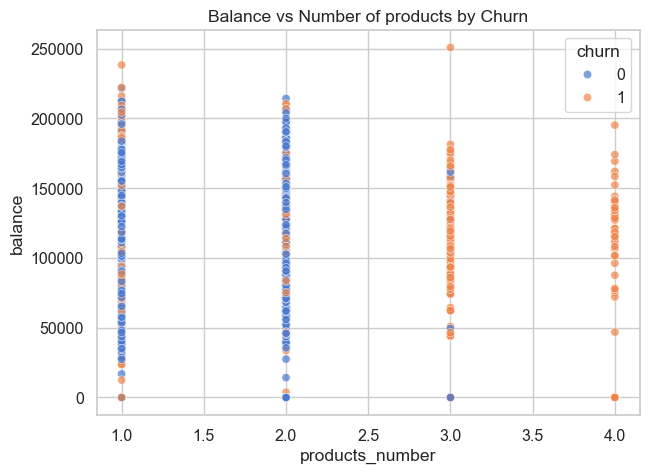

In [25]:
#----- Balance vs Products Scatter

plt.figure(figsize=(7,5))
sns.scatterplot(data= df,x='products_number',y='balance',hue='churn',alpha=0.7)
plt.title('Balance vs Number of products by Churn')
plt.show()

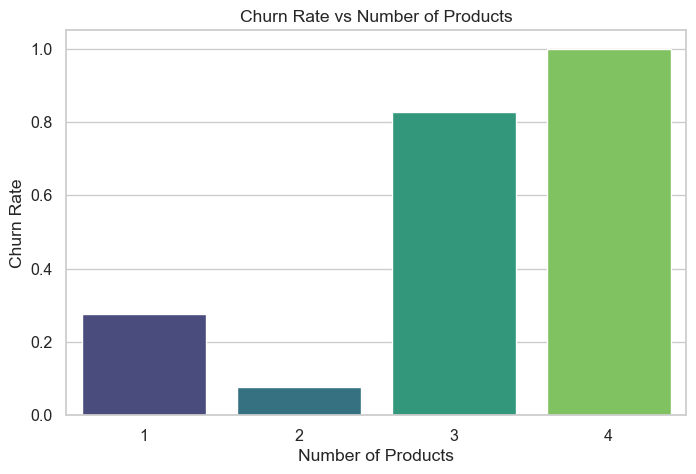

In [27]:
# ---- Aggregate churn rate per number of products
churn_rate = df.groupby('products_number')['churn'].mean().reset_index()

#plot churn rate
plt.figure(figsize=(8,5))
sns.barplot(data= churn_rate,x='products_number',y = 'churn',palette = 'viridis')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate')
plt.title('Churn Rate vs Number of Products')
plt.show()

Step 5 . Feature Engineering


Create meaninful features: e.g balance per product ,age group ,salary bracket and handle missing values

In [34]:
#feature engineering examples

df_fe = df.copy()


# Balance per product
df_fe['balance_per_product'] = df_fe['balance']/(df_fe['products_number'].replace(0,np.nan))
df_fe['balance_per_product'].fillna(0,inplace=True)


# salary balance ratio

df_fe['salary_balance_ratio'] = df_fe['estimated_salary']/(df_fe['balance'].replace(0,np.nan))
df_fe['salary_balance_ratio'].replace([np.inf,-np.inf],np.nan,inplace= True)
df_fe['salary_balance_ratio'].fillna(df_fe['salary_balance_ratio'].median(),inplace = True)

# Age group
bins=[0,25,35,45,55,65,100]
labels = ['<25','25-34','35-44','45-54','55-64','65+']
df_fe['age_group'] = pd.cut(df_fe['age'],bins= bins,labels= labels)


#tenure bucket
df_fe['tenure_bucket'] = pd.cut(df_fe['tenure'],bins=[-1,0,2,5,10,100],labels=['0','1-2','3-5','6-10','10+'])


#Flag high balance 
df_fe['high_balance'] = (df_fe['balance']>df_fe['balance'].quantile(0.75)).astype(int)

#Quick checks
df_fe[['balance_per_product','salary_balance_ratio','age','age_group','tenure','tenure_bucket','high_balance']].head()

,balance_per_product,salary_balance_ratio,age,age_group,tenure,tenure_bucket,high_balance
0,0.000000,NaN,42,35-44,2,1-2,0
1,83807.860000,1.342864,41,35-44,1,1-2,0
2,53220.266667,0.713585,42,35-44,8,6-10,1
3,0.000000,NaN,39,35-44,1,1-2,0
4,125510.820000,0.630098,43,35-44,2,1-2,0


step 6 . Preprocessing - encoding and scaling

In [35]:
# Define features and target
target = 'churn'
drop_cols = ['customer_id']

features = [c for c in df_fe.columns if c not in [target] + drop_cols]

# Numeric and categorical features
numeric_features = [
    'credit_score', 'age', 'tenure', 'balance',
    'products_number', 'estimated_salary',
    'balance_per_product', 'salary_balance_ratio'
]

categorical_features = [
    'country', 'gender', 'credit_card',
    'active_member', 'age_group',
    'tenure_bucket', 'high_balance'
]

# Ensure categorical columns are treated as objects
df_fe[categorical_features] = df_fe[categorical_features].astype('object')

# Pipelines
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Column transformer
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Print check
print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

Numeric features: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'balance_per_product', 'salary_balance_ratio']
Categorical features: ['country', 'gender', 'credit_card', 'active_member', 'age_group', 'tenure_bucket', 'high_balance']


Step 7 . Train Test split

In [37]:
X= df_fe[features]
y = df_fe[target]
X_train ,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
print('Train shape:', X_train.shape,'Test shape:',X_test.shape)
print('Train churn proportion:',y_train.mean(),'Test churn proportion:',y_test.mean())

Train shape: (8000, 15) Test shape: (2000, 15)
Train churn proportion: 0.20375 Test churn proportion: 0.2035


Step 8 . Train Multiple models with a pipeline and comapare using cross-validation

In [38]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=500),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    'SVC': SVC(probability=True, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', model)])
    
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    results[name] = scores
    
    print(f"{name} AUC: Mean={scores.mean():.4f} Std={scores.std():.4f}")

LogisticRegression AUC: Mean=0.7878 Std=0.0244
RandomForest AUC: Mean=0.8489 Std=0.0127
GradientBoosting AUC: Mean=0.8622 Std=0.0103
AdaBoost AUC: Mean=0.8462 Std=0.0133
SVC AUC: Mean=0.8351 Std=0.0104


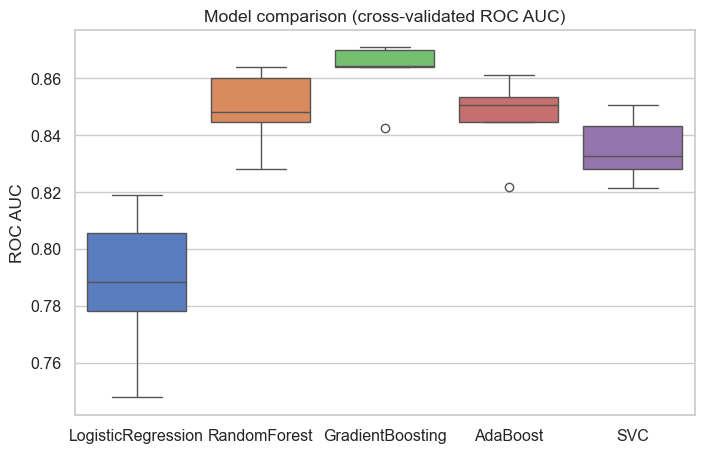

In [39]:

# Boxplot of CV AUC scores
plt.figure(figsize=(8,5))
sns.boxplot(data=[results[m] for m in list(results.keys())])
plt.xticks(ticks=range(len(results)), labels=list(results.keys()))
plt.ylabel('ROC AUC')
plt.title('Model comparison (cross-validated ROC AUC)')
plt.show()

Step 9: Fit best model on full train set and evaluate on test set

select best model by mean CV AUC above and evaluate standard metrics on the test set

In [40]:
# choose best model (automatic pick by mean AUC)
best_name = max(results.keys(),key= lambda k:results[k].mean())
best_name,results[best_name].mean()


('GradientBoosting', np.float64(0.8621659234717954))

Test Accuracy: 0.8645
Test Precision: 0.7698
Test Recall: 0.4767
Test F1-score: 0.5888
Test ROC AUC: 0.8687

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.77      0.48      0.59       407

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.86      0.85      2000



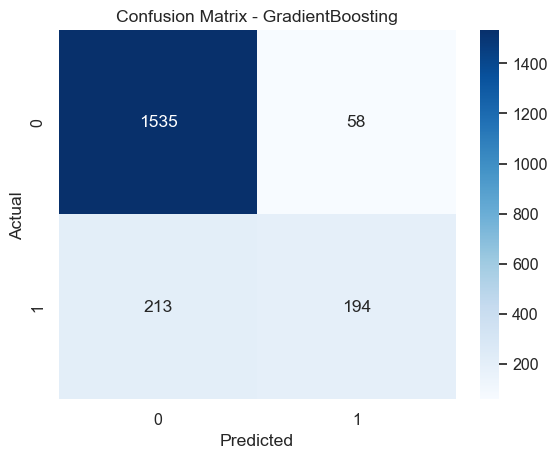

In [43]:
# Choose best model (automatic pick by mean AUC)
best_name = max(results.keys(), key=lambda k: results[k].mean())
best_name, results[best_name].mean()

best_model = models[best_name]

best_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', best_model)])

best_pipeline.fit(X_train, y_train)

# Predictions
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall: {rec:.4f}")
print(f"Test F1-score: {f1:.4f}")
print(f"Test ROC AUC: {roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

age                     0.327795
products_number         0.267303
balance_per_product     0.064717
balance                 0.052934
active_member_0         0.052485
country_Germany         0.050648
active_member_1         0.048412
salary_balance_ratio    0.028965
estimated_salary        0.026165
credit_score            0.023587
age_group_45-54         0.020738
age_group_55-64         0.008110
gender_Female           0.007837
gender_Male             0.005835
tenure                  0.005456
country_France          0.003275
tenure_bucket_3-5       0.001711
age_group_35-44         0.001395
country_Spain           0.000699
credit_card_1           0.000451
dtype: float64

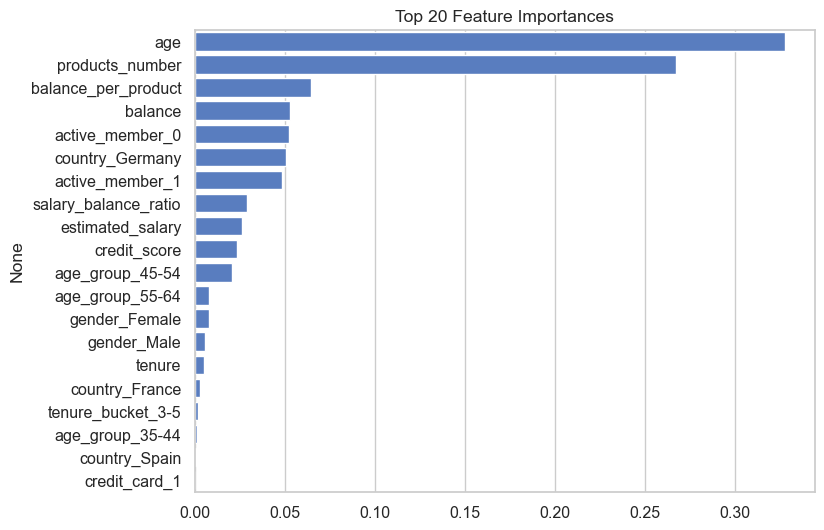

In [44]:
# Step 10. Feature importance (if applicable)

if hasattr(best_pipeline.named_steps['classifier'], 'feature_importances_'):
    num_feats = numeric_features
    cat_feats = list(best_pipeline.named_steps['preprocessor'].transformers_[1][1]
                     .named_steps['onehot'].get_feature_names_out(categorical_features))
    
    feature_names = num_feats + cat_feats
    importances = best_pipeline.named_steps['classifier'].feature_importances_
    
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:20]
    display(fi)
    
    plt.figure(figsize=(8,6))
    sns.barplot(x=fi.values, y=fi.index)
    plt.title('Top 20 Feature Importances')
    plt.show()
else:
    print("Selected model does not provide feature_importances_ attribute.")

step 11. Save the best pipeline and preprocessing artifacts


In [45]:
joblib.dump(best_pipeline, 'best_churn_pipeline.pkl')
print("Saved pipeline: best_churn_pipeline.pkl")

Saved pipeline: best_churn_pipeline.pkl


Step 12 Example: predict churn for a new customer

In [46]:
# --- New customer sample ---
sample = {
    'customer_id': 373292028,
    'credit_score': 650,
    'country': 'France',
    'gender': 'Male',
    'age': 40,
    'tenure': 3,
    'balance': 50000.0,
    'products_number': 2,
    'credit_card': 1,
    'active_member': 1,
    'estimated_salary': 60000.0
}

sample_df = pd.DataFrame([sample])

# --- Apply same feature engineering ---
sample_df['balance_per_product'] = sample_df['balance'] / (sample_df['products_number'].replace(0, np.nan))
sample_df['balance_per_product'].fillna(0, inplace=True)

sample_df['salary_balance_ratio'] = sample_df['estimated_salary'] / (sample_df['balance'].replace(0, np.nan))
sample_df['salary_balance_ratio'].replace([np.inf, -np.inf], np.nan, inplace=True)
sample_df['salary_balance_ratio'].fillna(sample_df['salary_balance_ratio'].median(), inplace=True)

bins = [0,25,35,45,55,65,100]
labels = ['<25','25-34','35-44','45-54','55-64','65+']
sample_df['age_group'] = pd.cut(sample_df['age'], bins=bins, labels=labels)

sample_df['tenure_bucket'] = pd.cut(sample_df['tenure'], bins=[-1,0,2,5,10,100], labels=['0','1-2','3-5','6-10','10+'])
sample_df['high_balance'] = (sample_df['balance'] > 50000.0).astype(int)  # can use 75th percentile of training set

# --- Drop ID ---
sample_df = sample_df.drop(columns=['customer_id'])

# --- Predict ---
pred = best_pipeline.predict(sample_df)[0]
prob = best_pipeline.predict_proba(sample_df)[0,1]

print(f"Predicted churn: {pred}, probability of churn: {prob:.3f}")

Predicted churn: 0, probability of churn: 0.029
